In [2]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import neurokit2 as nk

In [4]:
# Simulate ECG signals for two states: relaxed and stressed
np.random.seed(42)

def extract_hrv_features(state, n_samples=50):
    records = []
    for _ in range(n_samples):
        # Stressed = faster, less variable heart rate
        # Relaxed = slower, more variable heart rate
        if state == 1:  # stressed
            ecg = nk.ecg_simulate(duration=60, sampling_rate=250, heart_rate=90, noise=0.05)
        else:  # relaxed
            ecg = nk.ecg_simulate(duration=60, sampling_rate=250, heart_rate=65, noise=0.02)

        signals, info = nk.ecg_process(ecg, sampling_rate=250)
        rpeaks = info["ECG_R_Peaks"]
        rri = np.diff(rpeaks) / 250 * 1000  # Convert to milliseconds

        if len(rri) < 2:
            continue

        sdnn  = np.std(rri)
        rmssd = np.sqrt(np.mean(np.diff(rri)**2))
        pnn50 = np.sum(np.abs(np.diff(rri)) > 50) / len(rri) * 100
        mean_rri = np.mean(rri)

        records.append([sdnn, rmssd, pnn50, mean_rri, state])

    return records

stressed = extract_hrv_features(state=1, n_samples=50)
relaxed  = extract_hrv_features(state=0, n_samples=50)

df = pd.DataFrame(stressed + relaxed,
                  columns=["SDNN", "RMSSD", "pNN50", "Mean_RRI", "Label"])
print(df.head())
print(f"\nDataset shape: {df.shape}")

       SDNN     RMSSD  pNN50    Mean_RRI  Label
0  7.467699  6.848106    0.0  666.772727      1
1  7.467699  6.914918    0.0  666.772727      1
2  7.711615  7.214290    0.0  666.409091      1
3  7.302213  6.657465    0.0  666.363636      1
4  7.331016  6.404022    0.0  666.272727      1

Dataset shape: (100, 5)


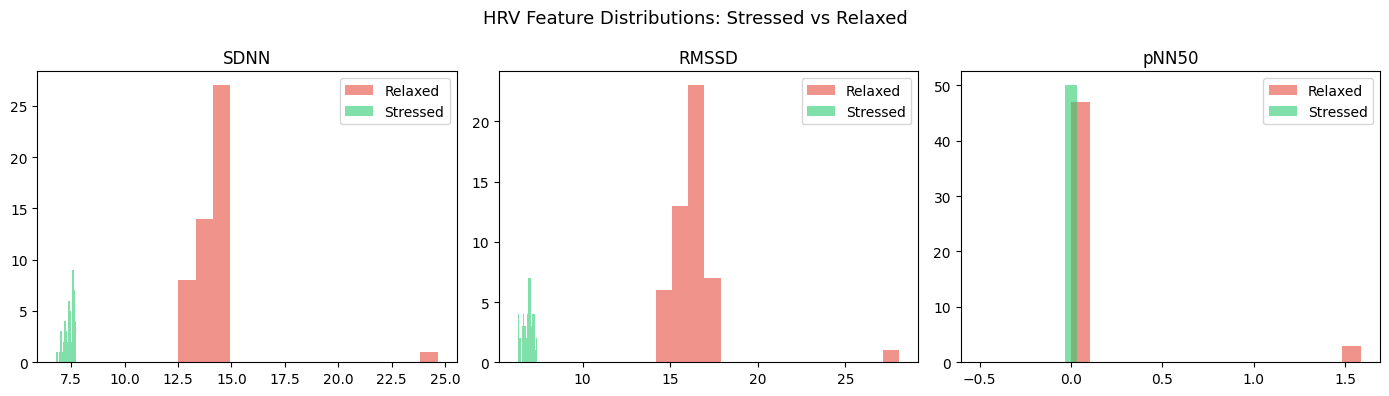

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features = ["SDNN", "RMSSD", "pNN50"]
colors = ["#e74c3c", "#2ecc71"]

for i, feat in enumerate(features):
    for label, color, name in zip([0, 1], colors, ["Relaxed", "Stressed"]):
        axes[i].hist(df[df["Label"]==label][feat],
                     alpha=0.6, color=color, label=name, bins=15)
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("HRV Feature Distributions: Stressed vs Relaxed", fontsize=13)
plt.tight_layout()
plt.savefig("hrv_features.png", dpi=150)
plt.show()

In [6]:
X = df[["SDNN", "RMSSD", "pNN50", "Mean_RRI"]]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 100.00%


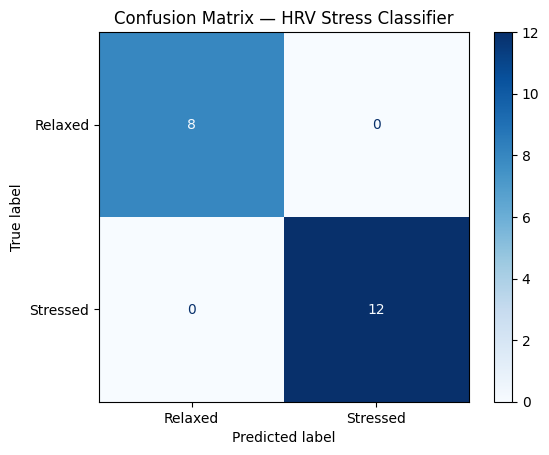

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Relaxed", "Stressed"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — HRV Stress Classifier")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

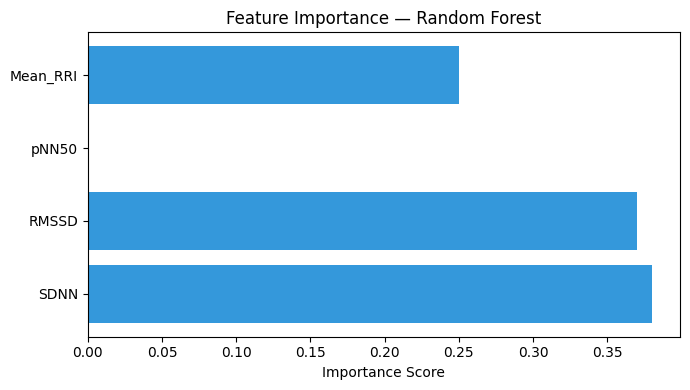

In [8]:
importances = model.feature_importances_
feat_names = ["SDNN", "RMSSD", "pNN50", "Mean_RRI"]

plt.figure(figsize=(7, 4))
plt.barh(feat_names, importances, color="#3498db")
plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()